# **MultiModal RAG App for Video Processing With LlamaIndex and LanceDB**

### 1. llamaindex framework
### 2. Lancedb Vector DataBase
### 3. LLM MultiModAl GPT-4V or Google-gemini-pro-vision


# **Steps Need to follow:**
#### 1. Download video from YouTube, process and store it.

#### 2. Build Multi-Modal index and vector store for both texts and images.

#### 3. Retrieve relevant images and context, use both to augment the prompt.

#### 4. Using GPT4V for reasoning the correlations between the input query and augmented data and generating final response.

In [74]:
%pip install llama-index-vector-stores-lancedb
# %pip install llama-index-multi-modal-llms-openai
%pip install llama-index-embeddings-clip
%pip install git+https://github.com/openai/CLIP.git
!pip install llama-index-readers-file
%pip install llama-index-embeddings-huggingface
%pip install groq

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-gjwly9m1
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-gjwly9m1
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done


In [75]:
%pip install llama_index
%pip install -U openai-whisper

In [76]:
%pip install lancedb
%pip install moviepy
%pip install pytube
%pip install pydub
%pip install SpeechRecognition
%pip install ffmpeg-python
%pip install soundfile
%pip install torch torchvision
%pip install matplotlib scikit-image
%pip install ftfy regex tqdm

ffmpeg-library enables you to use FFmpeg in Python to manipulate various media files for different purposes like building comprehensive multimedia applications, preprocessing media files.

MoviePy is a Python library for video editing, enabling cutting, concatenations, title insertions, video compositing, and effects like animations or color grading.

Pytube is a Python library used for downloading videos from YouTube. It supports downloading in various formats, resolutions, and also direct audio extraction.


Pydub is a Python library for audio manipulation, enabling easy loading,
editing, and exporting of audio files in various formats with minimal code.

The SpeechRecognition library in Python allows you to convert spoken language into text using various engines and APIs, such as Google Speech Recognition, IBM Speech to Text, etc.


SoundFile is a Python library for reading from and writing to audio files, supporting many formats through the libsndfile library, ideal for high-quality audio processing.

FTFY (Fix Text For You) is a Python library that fixes broken Unicode text and mojibake (garbled text due to encoding issues), making text legible again.

OpenAI Whisper is a robust, multilingual speech recognition model developed by OpenAI. It converts speech into text and supports various languages with high accuracy.

pprint is a Python module that provides a capability to "pretty-print" complex data structures in a well-formatted and more readable way than the basic print function.

In [77]:
from moviepy.editor import VideoFileClip
from pathlib import Path
import speech_recognition as sr
from pytube import YouTube
from pprint import pprint
from PIL import Image
import matplotlib.pyplot as plt

In [78]:
import os
from google.colab import userdata
#OPENAI_API_TOKEN=userdata.get('OPENAI_API_KEY')
#os.environ["OPENAI_API_KEY"] = OPENAI_API_TOKEN
GROQ_API_TOKEN=userdata.get('groq_api_key')
os.environ["GROQ_API_KEY"] = GROQ_API_TOKEN

GROQ_VISION_MODEL = "qwen/qwen3.6-27b"

In [79]:
import os
print(os.getcwd())

/content


In [80]:
video_url="https://www.youtube.com/watch?v=3dhcmeOTZ_Q"

In [81]:
output_video_path = "/content/video_data/"

In [82]:
# from the video i am going to collect images,audio,text
output_folder = "/content/mixed_data/"
output_audio_path = "/content/mixed_data/output_audio.wav"

In [10]:
!mkdir mixed_data

mkdir: cannot create directory ‘mixed_data’: File exists


In [83]:
filepath=output_video_path + "input_vid.mp4"
print(filepath)

/content/video_data/input_vid.mp4


In [12]:
%pip install --upgrade pytubefix

In [ ]:
#from pytube import YouTube
from pytubefix import YouTube

def download_video(url,output_path):
  yt = YouTube(url,client='WEB')
  yt.streams.get_highest_resolution()
  metadata = {"Author": yt.author, "Title": yt.title, "Views": yt.views}

  yt.streams.get_highest_resolution().download(
        output_path=output_path, filename="input_vid.mp4"
    )
  return metadata

In [22]:
!curl -fsSL https://deno.land/install.sh | sh

######################################################################## 100.0%
Archive:  /root/.deno/bin/deno.zip
  inflating: /root/.deno/bin/deno    
Deno was installed successfully to /root/.deno/bin/deno
sh: 105: cannot open /dev/tty: No such device or address


In [23]:
import os

os.environ["PATH"] = "/root/.deno/bin:" + os.environ["PATH"]

!deno --version

deno 2.9.6 (stable, release, x86_64-unknown-linux-gnu)
v8 15.0.245.2-rusty
typescript 6.0.3


In [25]:
import os
os.environ["PATH"] = "/root/.deno/bin:" + os.environ["PATH"]

In [28]:
import os
import shutil
import yt_dlp

os.environ["PATH"] = "/root/.deno/bin:" + os.environ["PATH"]

print("Deno:", shutil.which("deno"))
print("yt-dlp:", yt_dlp.version.__version__)

Deno: /root/.deno/bin/deno
yt-dlp: 2026.08.19


In [84]:
from moviepy.editor import VideoFileClip
def video_to_images(video_path,output_folder):
  clip=VideoFileClip(video_path)
  clip.write_images_sequence(
      os.path.join(output_folder,"frame%04d.png"),fps=0.2
  )

In [85]:
def video_to_audio(video_path,output_audio_path):
  clip=VideoFileClip(video_path)
  audio=clip.audio
  audio.write_audiofile(output_audio_path)

In [18]:
def audio_to_text(audio_path):
  recognizer=sr.Recognizer()
  audio=sr.AudioFile(audio_path)

  with audio as source:
    audio_data=recognizer.record(source)

    try:

      #recognize the speech
      text = recognizer.recognize_whisper(audio_data)

    except sr.UnknownValueError:
      print("Speech recognition could not understand the audio.")
  return text

In [86]:
video_url

'https://www.youtube.com/watch?v=3dhcmeOTZ_Q'

In [87]:
output_video_path

'/content/video_data/'

In [18]:
!pip install -U pytubefix nodejs-wheel-binaries

In [22]:
!pip install -U yt-dlp

In [23]:
!apt-get update -qq
!apt-get install -y ffmpeg -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [24]:
import yt_dlp

def download_video(url, output_path):

    options = {
        "format": "bestvideo+bestaudio/best",
        "outtmpl": f"{output_path}/input_vid.%(ext)s",
        "merge_output_format": "mp4",
    }

    with yt_dlp.YoutubeDL(options) as ydl:
        info = ydl.extract_info(url, download=True)

    metadata = {
        "Author": info.get("uploader"),
        "Title": info.get("title"),
        "Views": info.get("view_count"),
    }

    return metadata

In [25]:
metadata_vid = download_video(video_url, output_video_path)

[youtube] Extracting URL: https://www.youtube.com/watch?v=3dhcmeOTZ_Q
[youtube] 3dhcmeOTZ_Q: Downloading webpage


[youtube] 3dhcmeOTZ_Q: Downloading visionos player API JSON
[youtube] 3dhcmeOTZ_Q: Downloading m3u8 information
[info] 3dhcmeOTZ_Q: Downloading 1 format(s): 399+251-12


ERROR: unable to download video data: HTTP Error 403: Forbidden


DownloadError: ERROR: unable to download video data: HTTP Error 403: Forbidden

In [88]:
metadata_vid = {'Author': '3-Minute Data Science',
 'Title': 'Linear Regression in 3 Minutes',
 'Views': 365600}

In [89]:
video_to_images(filepath,output_folder)

Moviepy - Writing frames /content/mixed_data/frame%04d.png.


Moviepy - Done writing frames /content/mixed_data/frame%04d.png.


In [90]:
filepath

'/content/video_data/input_vid.mp4'

In [91]:
output_audio_path

'/content/mixed_data/output_audio.wav'

In [92]:
video_to_audio(filepath,output_audio_path)

MoviePy - Writing audio in /content/mixed_data/output_audio.wav


MoviePy - Done.


In [93]:
text_data=audio_to_text(output_audio_path)

In [94]:
text_data

" When you regression, as a statistical technique for modeling the relationship between an output variable and one or more input variables, in layman's terms, think of it as fitting a line through some data points as shown here so you can make predictions on unknown data, assuming there is a linear relationship between the variables. You might be familiar with the linear function y equals mx plus b, where y is the output variable, also called the dependent variable. You may also see expressed as f of x, the function of the input variable. x on the other hand would serve as the input variable, also called the independent variable. It's likely you'll see the coefficients m and b expressed as beta 1 and beta 0 respectively. So what do the m and b coefficients do? The m or beta 1 coefficient controls the slope of the line, the b or the beta 0 controls the intercept of the line, in machine learning we also know it as the bias. These two coefficients are what we are solving for in linear reg

In [95]:
with open(output_folder + "output_text.txt", "w") as file:
        file.write(text_data)
print("Text data saved to file")
file.close()


Text data saved to file


In [96]:
os.remove(output_audio_path)
print("Audio file removed")

Audio file removed


In [38]:
#process the video
#image
#text

In [97]:
from llama_index.core.indices import MultiModalVectorStoreIndex
from llama_index.core import SimpleDirectoryReader
from llama_index.core import StorageContext

In [98]:
# Swap the default (OpenAI) text-embedding model for a free, local one.
# Image embeddings already use CLIP by default, which is free/open-source.
from llama_index.core import Settings
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

# Runs locally (downloads once, no API key/cost). Good general-purpose small embedder.
Settings.embed_model = HuggingFaceEmbedding(model_name="BAAI/bge-small-en-v1.5")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [99]:
from llama_index.vector_stores.lancedb import LanceDBVectorStore

In [100]:
text_store=LanceDBVectorStore(uri="lancedb",table_name="text_collection")
image_store=LanceDBVectorStore(uri="lancedb",table_name="image_collection")

In [101]:
storage_context=StorageContext.from_defaults(vector_store=text_store,image_store=image_store)

In [102]:
output_folder

'/content/mixed_data/'

In [103]:
documents=SimpleDirectoryReader(output_folder).load_data()

In [104]:
index = MultiModalVectorStoreIndex.from_documents(documents,storage_context=storage_context)

In [105]:
retriever_engine=index.as_retriever(similarity_top_k=1, image_similarity_top_k=5)

In [106]:
from llama_index.core.response.notebook_utils import display_source_node
from llama_index.core.schema import ImageNode

In [107]:
def retrieve(retriever_engine, query_str):
    retrieval_results = retriever_engine.retrieve(query_str)

    retrieved_image = []
    retrieved_text = []
    for res_node in retrieval_results:
        if isinstance(res_node.node, ImageNode):
            retrieved_image.append(res_node.node.metadata["file_path"])
        else:
            display_source_node(res_node, source_length=200)
            retrieved_text.append(res_node.text)

    return retrieved_image, retrieved_text

In [108]:
query="can you tell me what is linear regression? explain equation of the multiple linear regression?"

In [109]:
img,text=retrieve(retriever_engine,query)

**Node ID:** 88910146-cd74-4f79-b4f0-a1d585f2a2dc<br>**Similarity:** 0.682574987411499<br>**Text:** When you regression, as a statistical technique for modeling the relationship between an output variable and one or more input variables, in layman's terms, think of it as fitting a line through so...<br>

In [110]:
import matplotlib.pyplot as plt
def plot_images(images_path):
  images_shown = 0
  plt.figure(figsize=(16, 9))
  for img_path in images_path:
        if os.path.isfile(img_path):
            image = Image.open(img_path)

            plt.subplot(2, 3, images_shown + 1)
            plt.imshow(image)
            plt.xticks([])
            plt.yticks([])

            images_shown += 1
            if images_shown >= 5:
                break

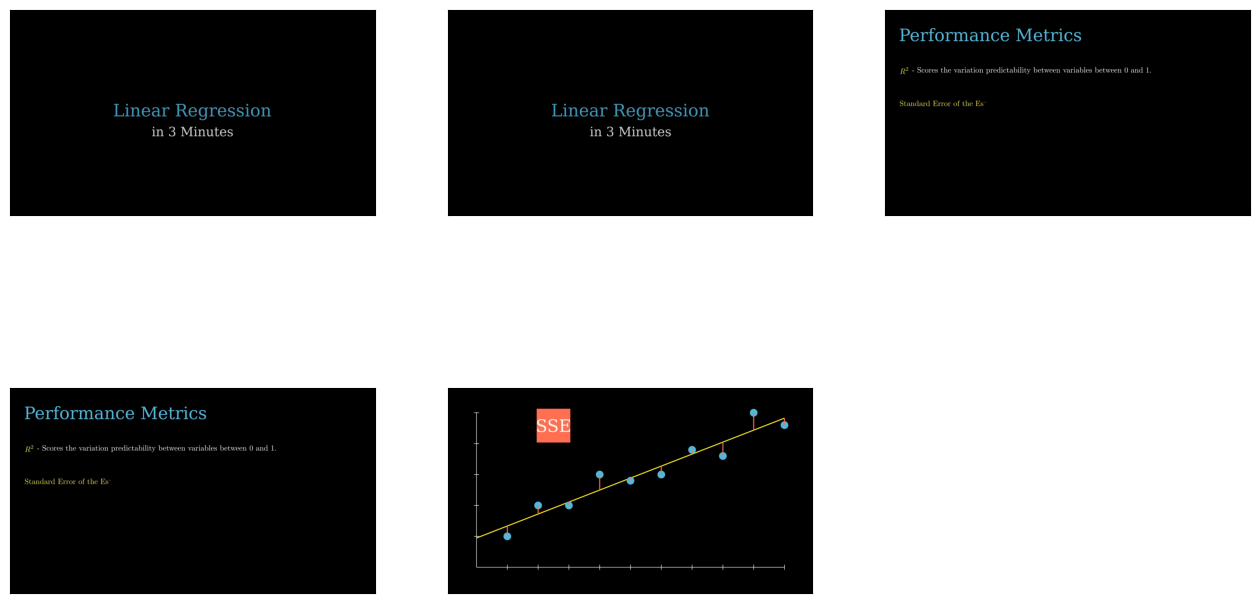

In [111]:
plot_images(img)

In [112]:
qa_tmpl_str=(
    "Based on the provided information, including relevant images and retrieved context from the video, \
    accurately and precisely answer the query without any additional prior knowledge.\n"

    "---------------------\n"
    "Context: {context_str}\n"
    "Metadata for video: {metadata_str} \n"

    "---------------------\n"
    "Query: {query_str}\n"
    "Answer: "
)

In [61]:
img

['/content/mixed_data/frame0003.png',
 '/content/mixed_data/frame0038.png',
 '/content/mixed_data/frame0028.png',
 '/content/mixed_data/frame0040.png',
 '/content/mixed_data/frame0041.png']

In [64]:
import json
metadata_str=json.dumps(metadata_vid)

In [65]:
query_str="can you tell me what is linear regression and equation of linear regression?"

In [66]:
context_str = "".join(text)

In [67]:
image_documents = SimpleDirectoryReader( input_files=img).load_data()

In [68]:
from llama_index.multi_modal_llms.openai import OpenAIMultiModal

In [ ]:
openai_mm_llm = OpenAIMultiModal(model="gpt-4-vision-preview", api_key=OPENAI_API_TOKEN, max_new_tokens=1500)

In [ ]:
result=openai_mm_llm.complete(
    prompt=qa_tmpl_str.format(
        query_str=query_str,metadata_str=metadata_str
    ),
    image_documents=image_documents,
)

In [69]:
!pip install -U langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 2.6 MB/s eta 0:00:00
  Attempting uninstall: groq
    Found existing installation: groq 1.7.0
    Uninstalling groq-1.7.0:
      Successfully uninstalled groq-1.7.0


In [72]:
import os
import base64
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

from google.colab import userdata
groq_api_key = userdata.get('groq_api_key')

def encode_image_base64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


# Initialize Groq through LangChain
llm = ChatGroq(
    model=GROQ_VISION_MODEL,
    api_key=groq_api_key,
    max_tokens=1500
)


def groq_vision_complete(prompt, image_paths):

    # Limit number of images if required by the selected model
    image_paths = image_paths[:3]

    content = [
        {
            "type": "text",
            "text": prompt
        }
    ]

    for p in image_paths:

        b64 = encode_image_base64(p)

        content.append(
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/png;base64,{b64}"
                }
            }
        )

    message = HumanMessage(content=content)

    response = llm.invoke([message])

    return response.content

In [73]:
result_text = groq_vision_complete(
    prompt=qa_tmpl_str.format(
        context_str=context_str, query_str=query_str, metadata_str=metadata_str
    ),
    image_paths=img,
)

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `qwen/qwen3.6-27b` in organization `org_01jgrpnn76emasp6gkd2bqwjad` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 8458, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [ ]:
pprint(result.text)

In [ ]:
qa_tmpl_str=(
    "Based on the provided information, including relevant images and retrieved context from the video, \
    accurately and precisely answer the query without any additional prior knowledge.\n"

    "---------------------\n"
    "Metadata for video: {metadata_str} \n"

    "---------------------\n"
    "Query: {query_str}\n"
    "Answer: "
)